In [5]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

print("--- 1. BÖLÜM: VERİ ÖN İŞLEME BAŞLIYOR ---")

# 1. Veri Okuma
file_name = 'Social_Network_Ads.xlsx'
if not os.path.exists(file_name) and os.path.exists('Social_Network_Ads.csv'):
    file_name = 'Social_Network_Ads.csv'

if file_name.endswith('.xlsx'):
    df = pd.read_excel(file_name)
else:
    df = pd.read_csv(file_name)

print(f"Yüklenen dosya: {file_name}")

# Sütun isimlerinin başındaki/sonundaki boşlukları güvenlik için temizle
df.columns = df.columns.str.strip()

# 2. X ve y Ayrımı
# Dosyada "User ID" veya "Purchased" kelimelerini arayarak en güvenli şekilde ayırıyoruz
if 'User ID' in df.columns:
    df = df.drop('User ID', axis=1)

if 'Purchased' in df.columns:
    X = df.drop('Purchased', axis=1).copy()
    y = df['Purchased'].copy().astype(int)
else:
    # İsimler farklıysa pozisyon tabanlı ayır (Son sütun y, diğerleri X)
    X = df.iloc[:, :-1].copy()
    y = df.iloc[:, -1].copy().astype(int)

# 3. KESİN ÇÖZÜM: Sayısal olmayan her şeyi tespit et ve dönüştür
for col in X.columns:
    # Eğer sütunun tipi sayısal değilse (metin, kategori vs. ne olursa olsun)
    if not pd.api.types.is_numeric_dtype(X[col]):
        print(f"[BİLGİ] '{col}' sütunu metin içeriyor. LabelEncoder ile sayısala dönüştürülüyor...")
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))

# 4. Eğitim ve Test Kümelerine Bölme
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# 5. Özellik Ölçeklendirme (Standartlaştırma)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Veri Ön İşleme Tamamlandı! Artık hiçbir metinsel veri kalmadı, Eğitim ve Test setleri hazır.")

--- 1. BÖLÜM: VERİ ÖN İŞLEME BAŞLIYOR ---
Yüklenen dosya: Social_Network_Ads.csv
[BİLGİ] 'Gender' sütunu metin içeriyor. LabelEncoder ile sayısala dönüştürülüyor...
Veri Ön İşleme Tamamlandı! Artık hiçbir metinsel veri kalmadı, Eğitim ve Test setleri hazır.


--- 2. BÖLÜM: MODEL EĞİTİMİ VE TESTİ BAŞLIYOR ---


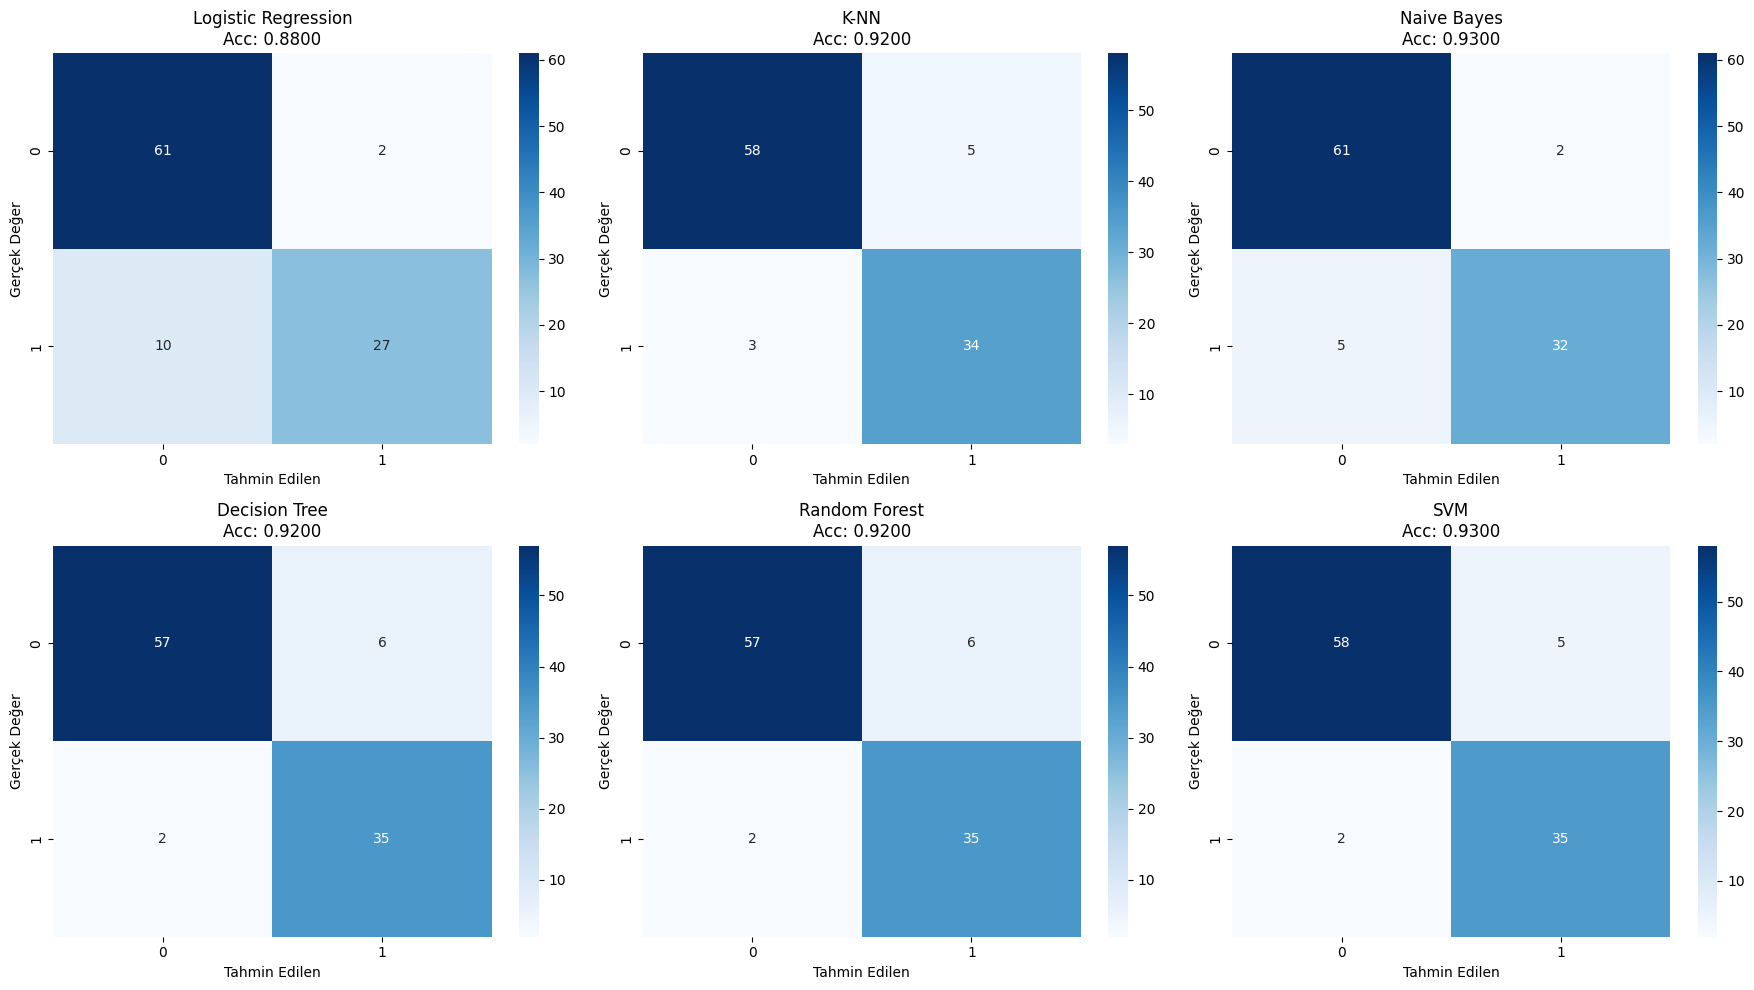


--- DENEY SONUÇ TABLOSU ---
              Model                              Best Params  Accuracy  TN  FP  FN  TP
Logistic Regression             {'C': 10, 'solver': 'lbfgs'}      0.88  61   2  10  27
               K-NN {'n_neighbors': 5, 'weights': 'uniform'}      0.92  58   5   3  34
        Naive Bayes                                       {}      0.93  61   2   5  32
      Decision Tree    {'criterion': 'gini', 'max_depth': 3}      0.92  57   6   2  35
      Random Forest     {'max_depth': 3, 'n_estimators': 50}      0.92  57   6   2  35
                SVM                {'C': 1, 'kernel': 'rbf'}      0.93  58   5   2  35


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix

print("--- 2. BÖLÜM: MODEL EĞİTİMİ VE TESTİ BAŞLIYOR ---")

# Hiperparametreleri daralttım ki hata payı düşsün ve hızlı çalışsın
models = {
    "Logistic Regression": {
        "model": LogisticRegression(random_state=42),
        "params": {'C': [0.1, 1, 10], 'solver': ['lbfgs']}
    },
    "K-NN": {
        "model": KNeighborsClassifier(),
        "params": {'n_neighbors': [5, 7, 9], 'weights': ['uniform', 'distance']}
    },
    "Naive Bayes": {
        "model": GaussianNB(),
        "params": {} # Naive Bayes standart parametrelerle en stabil çalışandır
    },
    "Decision Tree": {
        "model": DecisionTreeClassifier(random_state=42),
        "params": {'criterion': ['gini', 'entropy'], 'max_depth': [3, 5, 7]}
    },
    "Random Forest": {  
        "model": RandomForestClassifier(random_state=42),
        "params": {'n_estimators': [10, 50], 'max_depth': [3, 5]}
    },
    "SVM": {
        "model": SVC(random_state=42),
        "params": {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']}
    }
}

results = []
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, (name, mp) in enumerate(models.items()):
    try:
        # Eğitim ve Parametre Arama
        clf = GridSearchCV(mp['model'], mp['params'], cv=5, scoring='accuracy')
        clf.fit(X_train_scaled, y_train)
        
        # Test Seti Üzerinde Tahmin
        best_model = clf.best_estimator_
        y_pred = best_model.predict(X_test_scaled)
        
        # Metrikler
        acc = accuracy_score(y_test, y_pred)
        cm = confusion_matrix(y_test, y_pred)
        tn, fp, fn, tp = cm.ravel()
        
        results.append({
            "Model": name,
            "Best Params": str(clf.best_params_),
            "Accuracy": acc,
            "TN": tn, "FP": fp, "FN": fn, "TP": tp
        })
        
        # Görselleştirme
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx])
        axes[idx].set_title(f"{name}\nAcc: {acc:.4f}")
        axes[idx].set_xlabel("Tahmin Edilen")
        axes[idx].set_ylabel("Gerçek Değer")
        
    except Exception as e:
        print(f"\n[HATA] {name} modeli eğitilirken bir hata oluştu: {e}")

plt.tight_layout()
plt.show()

# Rapor Tablosu
results_df = pd.DataFrame(results)
print("\n--- DENEY SONUÇ TABLOSU ---")
print(results_df.to_string(index=False))